# PHY YOLO Pose Train

현재 수집 포맷의 port bbox와 4개 corner keypoint를 Ultralytics YOLO pose로 학습합니다.

- images: `images/<split>/<camera>/trial_<index>/*`
- annotations: `annotations/<split>/<camera>/trial_<index>/*.txt`
- metadata: `samples.jsonl`
- dataset config: `yolo_pose.yaml` (`kpt_shape: [4, 3]`)
- keypoint order: top-left, top-right, bottom-right, bottom-left

Class ID를 notebook에 고정하지 않고 `yolo_pose.yaml#names` 전체를 사용합니다. 따라서 SFP뿐 아니라 `sc_port` annotation이 추가되어도 같은 notebook으로 학습할 수 있습니다.

In [2]:
import importlib.util
import json
import os
import random
import subprocess
import sys
from collections import Counter
from pathlib import Path

IS_KAGGLE = Path("/kaggle/working").is_dir()
required_packages = {
    "hf_xet": "hf_xet",
    "huggingface_hub": "huggingface_hub",
    "matplotlib": "matplotlib",
    "torch": "torch",
    "ultralytics": "ultralytics",
    "yaml": "PyYAML",
}
missing_packages = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])
else :
    print("All required packages are already installed.")

import torch
import yaml

def find_src_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "pixi.toml").is_file() and (path / "phy").is_dir():
            return path
        nested = path / "ws_aic" / "src"
        if (nested / "pixi.toml").is_file() and (nested / "phy").is_dir():
            return nested
    raise RuntimeError("ws_aic/src root를 찾지 못했습니다.")


if IS_KAGGLE:
    SRC_ROOT = Path("/kaggle/working")
    WS_ROOT = SRC_ROOT
else:
    SRC_ROOT = find_src_root(Path.cwd())
    WS_ROOT = SRC_ROOT.parent
    
DATASET_ROOT = WS_ROOT / "data" / "img2pos" / "phy_approach"
DATASET_NAMES = ("board-view", "near-port")
DATASET_DIRS = {name: DATASET_ROOT / name for name in DATASET_NAMES}

MODEL_NAME = "yolo11s-pose.pt"
MODEL_ROOT = WS_ROOT / "model" / "phy_yolo_pose"
RUN_NAME = "all_views"

EPOCHS = 200
IMGSZ = 640
BATCH = 16
WORKERS = 8
PATIENCE = 20
IMAGE_EXTS = {".bmp", ".jpeg", ".jpg", ".png", ".tif", ".tiff", ".webp"}

CUDA_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
TORCH_CUDA_ARCHES = set(torch.cuda.get_arch_list())
CUDA_ARCH_BY_DEVICE = {}
for index in range(CUDA_COUNT):
    major, minor = torch.cuda.get_device_capability(index)
    CUDA_ARCH_BY_DEVICE[index] = f"sm_{major}{minor}"
CUDA_DEVICES = [index for index, arch in CUDA_ARCH_BY_DEVICE.items() if arch in TORCH_CUDA_ARCHES]
TRAIN_DEVICE = CUDA_DEVICES[:2] if len(CUDA_DEVICES) >= 2 else (CUDA_DEVICES[0] if CUDA_DEVICES else "cpu")
if IS_KAGGLE and CUDA_COUNT >= 2:
    assert TRAIN_DEVICE == [0, 1], f"Kaggle T4 x2 is not supported by this PyTorch build: {CUDA_ARCH_BY_DEVICE}"
INFERENCE_DEVICE = TRAIN_DEVICE[0] if isinstance(TRAIN_DEVICE, list) else TRAIN_DEVICE
if isinstance(TRAIN_DEVICE, list) and BATCH % len(TRAIN_DEVICE):
    raise ValueError(f"BATCH={BATCH} must be divisible by GPU count={len(TRAIN_DEVICE)}")


CACHE_ROOT = WS_ROOT / ".cache"
os.environ.setdefault("HF_HOME", str(CACHE_ROOT / "huggingface"))
os.environ.setdefault("HF_HUB_CACHE", str(CACHE_ROOT / "huggingface" / "hub"))
os.environ.setdefault("YOLO_CONFIG_DIR", str(CACHE_ROOT / "ultralytics"))

RUNTIME = "kaggle" if IS_KAGGLE else "local"
print(f"runtime: {RUNTIME}")
print(f"SRC_ROOT: {SRC_ROOT}")
print(f"DATASET_ROOT: {DATASET_ROOT}")
print(f"DATASETS: {DATASET_DIRS}")
print(f"TRAIN_DEVICE: {TRAIN_DEVICE}")
for index in range(CUDA_COUNT):
    print(f"GPU {index}: {torch.cuda.get_device_name(index)}, architecture={CUDA_ARCH_BY_DEVICE[index]}, supported={index in CUDA_DEVICES}")

All required packages are already installed.
runtime: local
SRC_ROOT: /home/swlinux/Desktop/workspace/aic-physic/ws_aic/src
DATASET_ROOT: /home/swlinux/Desktop/workspace/aic-physic/ws_aic/data/img2pos/phy_approach
DATASETS: {'board-view': PosixPath('/home/swlinux/Desktop/workspace/aic-physic/ws_aic/data/img2pos/phy_approach/board-view'), 'near-port': PosixPath('/home/swlinux/Desktop/workspace/aic-physic/ws_aic/data/img2pos/phy_approach/near-port')}
TRAIN_DEVICE: 0
GPU 0: NVIDIA GeForce RTX 3060, architecture=sm_86, supported=True


All required packages are already installed.
runtime: local
SRC_ROOT: /home/swlinux/Desktop/workspace/aic-physic/ws_aic/src
DATASET_ROOT: /home/swlinux/Desktop/workspace/aic-physic/ws_aic/data/img2pos/phy_approach
DATASETS: {'board-view': PosixPath('/home/swlinux/Desktop/workspace/aic-physic/ws_aic/data/img2pos/phy_approach/board-view'), 'near-port': PosixPath('/home/swlinux/Desktop/workspace/aic-physic/ws_aic/data/img2pos/phy_approach/near-port')}
TRAIN_DEVICE: 0
GPU 0: NVIDIA GeForce RTX 3060, architecture=sm_86, supported=True


## Hugging Face dataset download

`team-physic/aic-align`의 `260812` revision 전체를 `DATASET_ROOT`에 병렬 다운로드합니다. `board-view`와 `near-port`를 모두 보존합니다. Private dataset이면 Local에서는 `HF_TOKEN` 또는 `hf auth login`, Kaggle에서는 Secrets의 `HF_TOKEN`을 자동으로 읽습니다.

In [10]:
os.environ["HF_XET_HIGH_PERFORMANCE"] = "1"

from huggingface_hub import snapshot_download

HF_DATASET_REPO = "team-physic/aic-align"
HF_DATASET_REVISION = "260812"

import re
from pathlib import Path

SECRET_DIR = Path.home() / ".jupyter" / "secrets"


def get_secret(name: str) -> str:
    """~/.jupyter/secrets/<NAME>에서 Secret을 읽는다."""
    if not re.fullmatch(r"[A-Z][A-Z0-9_]*", name):
        raise ValueError("Secret 이름은 영문 대문자, 숫자, 밑줄만 사용할 수 있습니다.")

    path = SECRET_DIR / name

    try:
        value = path.read_text(encoding="utf-8").rstrip("\r\n")
    except FileNotFoundError as exc:
        raise KeyError(f"등록되지 않은 Secret: {name}") from exc

    if not value:
        raise ValueError(f"Secret 값이 비어 있습니다: {name}")

    return value
    
HF_TOKEN = get_secret("HF_TOKEN")
HF_TOKEN_SOURCE = "environment" if HF_TOKEN else "anonymous"
if IS_KAGGLE and not HF_TOKEN:
    try:
        from kaggle_secrets import UserSecretsClient
        HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
        HF_TOKEN_SOURCE = "Kaggle Secret"
    except Exception:
        HF_TOKEN = None

downloaded_dataset = snapshot_download(
    repo_id=HF_DATASET_REPO,
    repo_type="dataset",
    revision=HF_DATASET_REVISION,
    local_dir=DATASET_ROOT,
    token=HF_TOKEN or None,
    max_workers=4,
)
print(f"Downloaded revision: {downloaded_dataset}")
print(f"HF authentication: {HF_TOKEN_SOURCE}")

HF authentication: environment


HF authentication: environment


## Combined dataset config

`board-view`와 `near-port`의 YAML schema를 검사합니다. 원본 파일은 수정하지 않고 두 dataset의 모든 split을 `model/phy_yolo_pose/combined_dataset` 아래 상대 symlink로 합칩니다.

In [3]:
DATASET_CONFIGS = {}
CLASS_NAMES = None
KPT_SHAPE = None

for dataset_name, dataset_dir in DATASET_DIRS.items():
    yaml_path = dataset_dir / "yolo_pose.yaml"
    samples_path = dataset_dir / "samples.jsonl"
    annotations_dir = dataset_dir / "annotations"
    for required_path in (yaml_path, samples_path, annotations_dir):
        if not required_path.exists():
            raise FileNotFoundError(required_path)

    dataset_cfg = yaml.safe_load(yaml_path.read_text(encoding="utf-8")) or {}
    raw_names = dataset_cfg.get("names", {})
    class_names = (
        {index: str(name) for index, name in enumerate(raw_names)}
        if isinstance(raw_names, list)
        else {int(index): str(name) for index, name in raw_names.items()}
    )
    kpt_shape = tuple(map(int, dataset_cfg["kpt_shape"]))
    if kpt_shape != (4, 3):
        raise ValueError(f"{dataset_name}: expected kpt_shape [4, 3], got {list(kpt_shape)}")
    if not class_names:
        raise ValueError(f"{dataset_name}: yolo_pose.yaml#names is empty")
    if CLASS_NAMES is None:
        CLASS_NAMES, KPT_SHAPE = class_names, kpt_shape
    elif class_names != CLASS_NAMES or kpt_shape != KPT_SHAPE:
        raise ValueError(f"incompatible dataset schema: {dataset_name}")
    DATASET_CONFIGS[dataset_name] = {
        "dir": dataset_dir,
        "cfg": dataset_cfg,
        "samples": samples_path,
        "annotations": annotations_dir,
    }

KPT_COUNT, KPT_DIMS = KPT_SHAPE


def prepare_training_view() -> Path:
    view_dir = MODEL_ROOT / "combined_dataset"
    for dataset_name, dataset in DATASET_CONFIGS.items():
        for split in ("train", "val", "test"):
            if split not in dataset["cfg"]:
                continue
            image_target = dataset["dir"] / str(dataset["cfg"][split])
            label_target = dataset["annotations"] / split
            for kind, target in (("images", image_target), ("labels", label_target)):
                if not target.is_dir():
                    raise FileNotFoundError(target)
                link = view_dir / kind / split / dataset_name
                link.parent.mkdir(parents=True, exist_ok=True)
                relative_target = Path(os.path.relpath(target, link.parent))
                if link.is_symlink():
                    if link.readlink() != relative_target:
                        raise ValueError(f"unexpected symlink target: {link}")
                elif link.exists():
                    raise FileExistsError(link)
                else:
                    link.symlink_to(relative_target, target_is_directory=True)

    train_cfg = dict(next(iter(DATASET_CONFIGS.values()))["cfg"])
    train_cfg["path"] = str(view_dir)
    for split in ("train", "val", "test"):
        if any(split in dataset["cfg"] for dataset in DATASET_CONFIGS.values()):
            train_cfg[split] = f"images/{split}"
        else:
            train_cfg.pop(split, None)
    train_yaml = view_dir / "yolo_pose.yaml"
    train_yaml.write_text(
        yaml.safe_dump(train_cfg, sort_keys=False, allow_unicode=True),
        encoding="utf-8",
    )
    return train_yaml


print(f"datasets: {list(DATASET_CONFIGS)}")
print(f"classes: {CLASS_NAMES}")
print(f"kpt_shape: {[KPT_COUNT, KPT_DIMS]}")

datasets: ['board-view', 'near-port']
classes: {0: 'SFP_00', 1: 'SFP_01', 2: 'SFP_10', 3: 'SFP_11', 4: 'SFP_20', 5: 'SFP_21', 6: 'SFP_30', 7: 'SFP_31', 8: 'SFP_40', 9: 'SFP_41', 10: 'sc_port'}
kpt_shape: [4, 3]


datasets: ['board-view', 'near-port']
classes: {0: 'SFP_00', 1: 'SFP_01', 2: 'SFP_10', 3: 'SFP_11', 4: 'SFP_20', 5: 'SFP_21', 6: 'SFP_30', 7: 'SFP_31', 8: 'SFP_40', 9: 'SFP_41', 10: 'sc_port'}
kpt_shape: [4, 3]


## Combined dataset validation

두 dataset 각각의 split 경로, image/annotation 1:1 대응, YOLO pose row, class ID, 좌표, visibility, `samples.jsonl` 참조를 검사하고 합산 개수를 출력합니다.

In [4]:
def split_dir(dataset_name: str, split: str) -> Path:
    dataset = DATASET_CONFIGS[dataset_name]
    value = Path(str(dataset["cfg"][split]))
    if value.is_absolute():
        raise ValueError(f"{dataset_name}/{split} path must be relative: {value}")
    return dataset["dir"] / value


def iter_images(path: Path) -> list[Path]:
    return sorted(
        candidate
        for candidate in path.rglob("*")
        if candidate.is_file() and candidate.suffix.lower() in IMAGE_EXTS
    )


def annotation_for(dataset_name: str, image_path: Path) -> Path:
    dataset = DATASET_CONFIGS[dataset_name]
    relative = image_path.relative_to(dataset["dir"] / "images")
    return (dataset["annotations"] / relative).with_suffix(".txt")


def validate_annotation(path: Path) -> list[str]:
    errors = []
    expected_fields = 5 + KPT_COUNT * KPT_DIMS
    for line_number, line in enumerate(path.read_text(encoding="utf-8").splitlines(), 1):
        fields = line.split()
        if not fields:
            continue
        if len(fields) != expected_fields:
            errors.append(f"{path}:{line_number}: expected {expected_fields} fields, got {len(fields)}")
            continue
        try:
            class_id = int(fields[0])
            values = [float(value) for value in fields[1:]]
        except ValueError:
            errors.append(f"{path}:{line_number}: invalid number")
            continue
        if class_id not in CLASS_NAMES:
            errors.append(f"{path}:{line_number}: unknown class_id {class_id}")
        bbox = values[:4]
        if any(value < 0.0 or value > 1.0 for value in bbox):
            errors.append(f"{path}:{line_number}: bbox outside [0, 1]")
        if bbox[2] <= 0.0 or bbox[3] <= 0.0:
            errors.append(f"{path}:{line_number}: bbox width/height must be positive")
        for index in range(4, len(values), KPT_DIMS):
            x, y, visibility = values[index:index + 3]
            if not (0.0 <= x <= 1.0 and 0.0 <= y <= 1.0):
                errors.append(f"{path}:{line_number}: keypoint outside [0, 1]")
            if visibility not in (0.0, 1.0, 2.0):
                errors.append(f"{path}:{line_number}: visibility must be 0, 1, or 2")
    return errors


errors = []
dataset_images = set()
sample_images = set()
split_counts = Counter()
connector_counts = Counter()
camera_counts = Counter()

for dataset_name, dataset in DATASET_CONFIGS.items():
    for split in ("train", "val", "test"):
        if split not in dataset["cfg"]:
            continue
        image_root = split_dir(dataset_name, split)
        images = iter_images(image_root)
        split_counts[split] += len(images)
        dataset_images.update(
            f"{dataset_name}/{path.relative_to(dataset['dir']).as_posix()}" for path in images
        )
        if split in ("train", "val") and not images:
            errors.append(f"{dataset_name}/{split}: no images under {image_root}")
        expected_annotations = {annotation_for(dataset_name, path) for path in images}
        annotation_root = dataset["annotations"] / split
        actual_annotations = set(annotation_root.rglob("*.txt")) if annotation_root.exists() else set()
        errors.extend(f"missing annotation: {path}" for path in sorted(expected_annotations - actual_annotations))
        errors.extend(f"orphan annotation: {path}" for path in sorted(actual_annotations - expected_annotations))
        for annotation_path in sorted(actual_annotations):
            errors.extend(validate_annotation(annotation_path))

    for line_number, line in enumerate(dataset["samples"].read_text(encoding="utf-8").splitlines(), 1):
        try:
            row = json.loads(line)
        except json.JSONDecodeError as exc:
            errors.append(f"{dataset_name}/samples.jsonl:{line_number}: {exc}")
            continue
        connector_counts[str(row.get("connector", "unknown"))] += 1
        for camera, relative_image in row.get("images", {}).items():
            sample_images.add(f"{dataset_name}/{relative_image}")
            camera_counts[camera] += 1
            if not (dataset["dir"] / relative_image).is_file():
                errors.append(f"{dataset_name}/samples.jsonl:{line_number}: missing image {relative_image}")
            relative_annotation = row.get("annotations", {}).get(camera)
            if relative_annotation is None or not (dataset["dir"] / relative_annotation).is_file():
                errors.append(f"{dataset_name}/samples.jsonl:{line_number}: missing annotation for {camera}")

errors.extend(f"image missing from samples.jsonl: {path}" for path in sorted(dataset_images - sample_images))
errors.extend(f"samples.jsonl references unknown image: {path}" for path in sorted(sample_images - dataset_images))

print(f"split images: {dict(split_counts)}")
print(f"total images: {len(dataset_images)}")
print(f"connectors: {dict(connector_counts)}")
print(f"cameras: {dict(camera_counts)}")
print(f"classes: {CLASS_NAMES}")
if errors:
    preview = "\n".join(errors[:100])
    raise ValueError(f"Dataset validation failed with {len(errors)} errors.\n{preview}")
print(f"OK: images={len(dataset_images)}, expected label fields={5 + KPT_COUNT * KPT_DIMS}")

split images: {'train': 12276, 'val': 2604, 'test': 2361}
total images: 17241
connectors: {'unknown': 5747}
cameras: {'left': 5747, 'center': 5747, 'right': 5747}
classes: {0: 'SFP_00', 1: 'SFP_01', 2: 'SFP_10', 3: 'SFP_11', 4: 'SFP_20', 5: 'SFP_21', 6: 'SFP_30', 7: 'SFP_31', 8: 'SFP_40', 9: 'SFP_41', 10: 'sc_port'}
OK: images=17241, expected label fields=17


split images: {'train': 12276, 'val': 2604, 'test': 2361}
total images: 17241
connectors: {'unknown': 5747}
cameras: {'left': 5747, 'center': 5747, 'right': 5747}
classes: {0: 'SFP_00', 1: 'SFP_01', 2: 'SFP_10', 3: 'SFP_11', 4: 'SFP_20', 5: 'SFP_21', 6: 'SFP_30', 7: 'SFP_31', 8: 'SFP_40', 9: 'SFP_41', 10: 'sc_port'}
OK: images=17241, expected label fields=17


## Train all images

두 dataset의 같은 split끼리 결합합니다. `board-view/train + near-port/train`은 학습, 두 `val`은 검증, 두 `test`는 보류합니다. `classes` 인자를 넘기지 않아 YAML의 모든 class를 사용합니다. `TRAIN_DEVICE=[0, 1]`이면 Ultralytics DDP로 Kaggle T4 두 개를 사용합니다.

In [9]:
from ultralytics import YOLO

TRAIN_YAML = prepare_training_view()
model = YOLO(MODEL_NAME)
train_results = model.train(
    data=str(TRAIN_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    project=str(MODEL_ROOT),
    name=RUN_NAME,
    patience=PATIENCE,
    save=True,
    save_period=10,
    plots=True,
    device=TRAIN_DEVICE,
    workers=WORKERS,
    fliplr=0.0,
    flipud=0.0,
)

RUN_DIR = Path(model.trainer.save_dir)
BEST_PT = RUN_DIR / "weights" / "best.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"
print(f"run: {RUN_DIR}")
print(f"best: {BEST_PT}")

New https://pypi.org/project/ultralytics/8.4.120 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.118 🚀 Python-3.12.3 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060, 11903MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/swlinux/Desktop/workspace/aic-physic/ws_aic/model/phy_yolo_pose/combined_dataset/yolo_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.

KeyboardInterrupt: 

## Resume or validate

필요한 셀만 주석을 해제해 실행합니다.

In [ ]:
# 완전 재개
# model = YOLO(str(LAST_PT))
# train_results = model.train(resume=True)

# 학습 없이 validation
# model = YOLO(str(BEST_PT))
# metrics = model.val(
#     data=str(TRAIN_YAML), imgsz=IMGSZ, batch=BATCH, device=INFERENCE_DEVICE
# )
# print(metrics)

## Prediction preview

WARNING ⚠️ user config directory '/home/swlinux/Desktop/workspace/aic-physic/ws_aic/.cache/ultralytics/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /home/swlinux/Desktop/workspace/aic-physic/ws_aic/data/img2pos/phy_approach/near-port/images/val/left/trial_003/sfp_card_10111_rail0_port0_num011_left.jpg: 576x640 1 SFP_00, 1 SFP_01, 1 SFP_20, 1 SFP_21, 6.3ms
Speed: 29.6ms preprocess, 6.3ms inference, 23.2ms postprocess per image at shape (1, 3, 576, 640)
Results saved to /home/swlinux/Desktop/workspace/aic-physic/ws_aic/model/phy_yolo_pose/all_views_predict
/home/swlinux/Desktop/workspace/aic-physic/ws_aic/data/img2pos/phy_approach/near-p

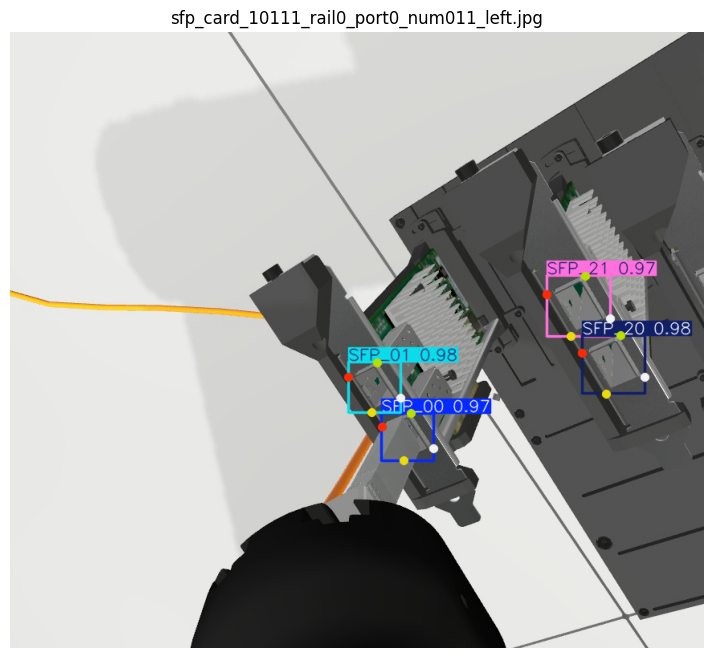

WARNING ⚠️ user config directory '/home/swlinux/Desktop/workspace/aic-physic/ws_aic/.cache/ultralytics/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /home/swlinux/Desktop/workspace/aic-physic/ws_aic/data/img2pos/phy_approach/near-port/images/val/left/trial_003/sfp_card_10111_rail0_port0_num011_left.jpg: 576x640 1 SFP_00, 1 SFP_01, 1 SFP_20, 1 SFP_21, 6.3ms
Speed: 29.6ms preprocess, 6.3ms inference, 23.2ms postprocess per image at shape (1, 3, 576, 640)
Results saved to /home/swlinux/Desktop/workspace/aic-physic/ws_aic/model/phy_yolo_pose/all_views_predict
/home/swlinux/Desktop/workspace/aic-physic/ws_aic/data/img2pos/phy_approach/near-p

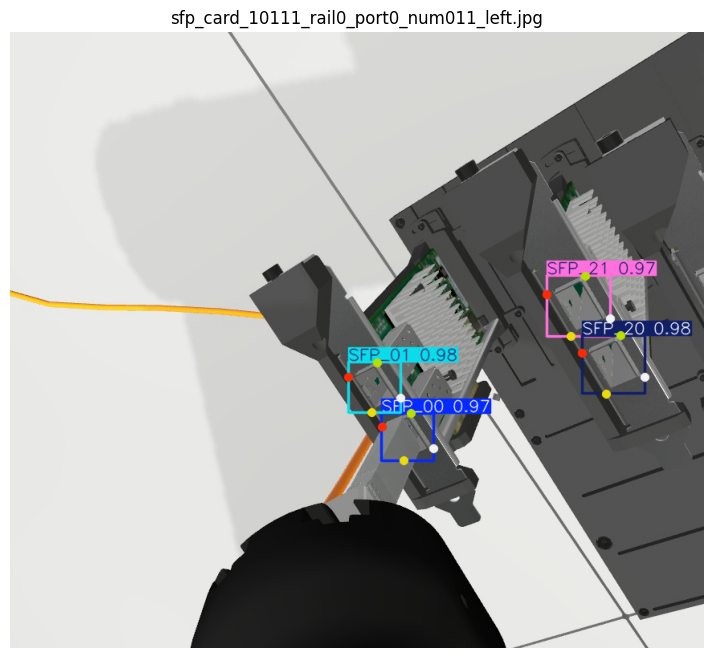

In [6]:
import matplotlib.pyplot as plt
from ultralytics import YOLO

RUN_DIR = MODEL_ROOT / RUN_NAME
BEST_PT = RUN_DIR / "weights" / "best.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"
if not BEST_PT.is_file():
    raise FileNotFoundError(f"completed checkpoint not found: {BEST_PT}")

preview_images = []
for dataset_name in DATASET_NAMES:
    dataset_cfg = DATASET_CONFIGS[dataset_name]["cfg"]
    split = "val" if "val" in dataset_cfg else "train"
    preview_images.extend(iter_images(split_dir(dataset_name, split)))
sample = random.choice(preview_images)
model = YOLO(str(BEST_PT))
prediction = model.predict(
    source=str(sample),
    imgsz=IMGSZ,
    device=INFERENCE_DEVICE,
    save=True,
    project=str(MODEL_ROOT),
    name=f"{RUN_NAME}_predict",
)
annotated_bgr = prediction[0].plot()
plt.figure(figsize=(10, 8))
plt.imshow(annotated_bgr[..., ::-1])
plt.axis("off")
plt.title(sample.name)
print(sample)

## Upload best model, Model Card, and diagnostics to Hugging Face

학습이 끝난 뒤 완료된 `all_views` run의 `best.pt`, Model Card, 진단 산출물을 한 commit으로 업로드합니다. `team-physic/aic-approach` model repository가 없으면 비공개 repository로 생성하고, `0814-001` branch(revision)가 없으면 생성합니다. Repository와 branch가 이미 있으면 재사용하며 `main`은 변경하지 않습니다.

실행 폴더 루트에 생성된 `results.csv`, `args.yaml`, Box/Pose 곡선, confusion matrix, label·train/validation batch 이미지 등 모든 파일은 `diagnosis/` 아래에 자동 업로드합니다. `diagnosis/README.md`에는 실제 학습 시간, best/latest 지표, 파일별 크기와 SHA-256, 누락 검사 및 디버깅·검증 절차를 기록합니다. `~/.jupyter/secrets/HF_TOKEN`에는 `team-physic` organization에서 model repository를 생성하고 쓸 수 있는 권한이 필요합니다.

In [ ]:
import csv
import hashlib
from datetime import timedelta

from huggingface_hub import CommitOperationAdd, HfApi

HF_DATASET_REPO = "team-physic/aic-align"
HF_DATASET_REVISION = "260812"

HF_MODEL_REPO = "team-physic/aic-approach"
HF_MODEL_REVISION = "0814-001"
HF_MODEL_PRIVATE = True

RUN_DIR = MODEL_ROOT / RUN_NAME
BEST_PT = RUN_DIR / "weights" / "best.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"
RESULTS_CSV = RUN_DIR / "results.csv"

if not BEST_PT.is_file():
    raise FileNotFoundError(f"trained checkpoint not found: {BEST_PT}")
if not RESULTS_CSV.is_file():
    raise FileNotFoundError(f"training results not found: {RESULTS_CSV}")

with RESULTS_CSV.open(newline="", encoding="utf-8") as file:
    result_rows = list(csv.DictReader(file))
if not result_rows:
    raise ValueError(f"training results are empty: {RESULTS_CSV}")

last_result = result_rows[-1]
completed_epochs = int(float(last_result["epoch"]))
training_seconds = float(last_result["time"])
training_duration = str(timedelta(seconds=round(training_seconds)))


def metric(row, key):
    return float(row[key])


best_result = max(
    result_rows,
    key=lambda row: metric(row, "metrics/mAP50-95(B)")
    + metric(row, "metrics/mAP50-95(P)"),
)
best_epoch = int(float(best_result["epoch"]))


def sha256_file(file_path):
    digest = hashlib.sha256()
    with file_path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


best_sha256 = sha256_file(BEST_PT)
diagnostic_files = sorted(file_path for file_path in RUN_DIR.iterdir() if file_path.is_file())

expected_diagnostics = {
    "args.yaml",
    "results.csv",
    "results.png",
    "labels.jpg",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxPR_curve.png",
    "BoxR_curve.png",
    "PoseF1_curve.png",
    "PoseP_curve.png",
    "PosePR_curve.png",
    "PoseR_curve.png",
}
diagnostic_names = {file_path.name for file_path in diagnostic_files}
missing_diagnostics = sorted(expected_diagnostics - diagnostic_names)
missing_diagnostics_text = (
    "None"
    if not missing_diagnostics
    else ", ".join(f"`{name}`" for name in missing_diagnostics)
)

manifest_rows = "\n   ".join(
    f"| [`{file_path.name}`](./{file_path.name}) | {file_path.stat().st_size:,} | `{sha256_file(file_path)}` |"
    for file_path in diagnostic_files
)

split_rows = "\n   ".join(
    f"| `{split}` | {split_counts.get(split, 0)} |" for split in ("train", "val", "test")
)
class_rows = "\n   ".join(
    f"| {class_id} | `{class_name}` |" for class_id, class_name in sorted(CLASS_NAMES.items())
)
dataset_names = ", ".join(f"`{name}`" for name in DATASET_NAMES)

model_card = f"""---
library_name: ultralytics
tags:
- ultralytics
- yolo
- pose-estimation
datasets:
- {HF_DATASET_REPO}
---

# AIC Approach YOLO Pose ({HF_MODEL_REVISION})

## 모델 파일

- 체크포인트: `best.pt`
- 학습 실행 이름: `{RUN_NAME}`
- 실행 환경: `{RUNTIME}`
- 완료 epoch: `{completed_epochs}` / 설정 `{EPOCHS}`
- 실제 학습 시간: `{training_duration}` (`{training_seconds:.1f}`초, Ultralytics `results.csv` 기준)
- 진단 보고서: [`diagnosis/README.md`](./diagnosis/README.md)

## 학습 데이터셋

- 저장소: [`{HF_DATASET_REPO}`](https://huggingface.co/datasets/{HF_DATASET_REPO})
- revision: `{HF_DATASET_REVISION}`
- 포함 디렉터리: {dataset_names}
- 전체 이미지: {len(dataset_images)}
- 커넥터 분포: `{dict(connector_counts)}`
- 카메라 분포: `{dict(camera_counts)}`

| 분할 | 이미지 수 |
|---|---:|
{split_rows}

## 모델 구성

- 프레임워크: Ultralytics YOLO Pose
- 초기 체크포인트: `{MODEL_NAME}`
- 출력: bounding box + {KPT_COUNT}개 keypoint × {KPT_DIMS}개 값

| 클래스 ID | 클래스 이름 |
|---:|---|
{class_rows}

## 학습 설정

| 항목 | 값 |
|---|---|
| 설정 epoch | `{EPOCHS}` |
| 완료 epoch | `{completed_epochs}` |
| 실제 학습 시간 | `{training_duration}` (`{training_seconds:.1f}`초) |
| 이미지 크기 | `{IMGSZ}` |
| batch | `{BATCH}` |
| workers | `{WORKERS}` |
| patience | `{PATIENCE}` |
| device | `{TRAIN_DEVICE}` |
| save period | `10` |
| fliplr | `0.0` |
| flipud | `0.0` |

## 진단 자료

이 revision에는 학습 실행 폴더에서 수집한 진단 파일 {len(diagnostic_files)}개가 [`diagnosis/`](./diagnosis/)에 포함됩니다.

[`diagnosis/README.md`](./diagnosis/README.md)에서 다음 내용을 확인할 수 있습니다.

- Box/Pose F1·Precision·Recall·PR 곡선의 축과 해석 방법
- 원시/정규화 confusion matrix의 축과 오류 유형
- train/validation loss를 이용한 과적합 판단
- 라벨·증강·예측 이미지의 시각 검증 방법
- best/latest 지표, 필수 산출물 누락 여부, 파일별 SHA-256
"""

diagnostics_readme = f"""# 학습 진단 자료

이 디렉터리는 `{RUN_NAME}` 학습 실행 폴더의 루트에 생성된 모든 일반 파일과 검증 절차를 보존합니다.

## 실행 요약

| 항목 | 값 |
|---|---:|
| 설정 epoch | {EPOCHS} |
| 완료 epoch | {completed_epochs} |
| 실제 학습 시간 | {training_duration} ({training_seconds:.1f}초) |
| best epoch | {best_epoch} |
| best Box mAP50-95 | {metric(best_result, "metrics/mAP50-95(B)"):.5f} |
| best Pose mAP50-95 | {metric(best_result, "metrics/mAP50-95(P)"):.5f} |
| 마지막 Box precision / recall | {metric(last_result, "metrics/precision(B)"):.5f} / {metric(last_result, "metrics/recall(B)"):.5f} |
| 마지막 Box mAP50 / mAP50-95 | {metric(last_result, "metrics/mAP50(B)"):.5f} / {metric(last_result, "metrics/mAP50-95(B)"):.5f} |
| 마지막 Pose precision / recall | {metric(last_result, "metrics/precision(P)"):.5f} / {metric(last_result, "metrics/recall(P)"):.5f} |
| 마지막 Pose mAP50 / mAP50-95 | {metric(last_result, "metrics/mAP50(P)"):.5f} / {metric(last_result, "metrics/mAP50-95(P)"):.5f} |
| `best.pt` SHA-256 | `{best_sha256}` |
| 누락된 핵심 진단 파일 | {missing_diagnostics_text} |

best epoch는 Ultralytics Pose fitness 기준인 `Box mAP50-95 + Pose mAP50-95`가 가장 큰 epoch로 계산합니다. 마지막 epoch와 best epoch가 다를 수 있으며 배포에는 일반적으로 `best.pt`를 사용합니다.

## 그래프별 의미와 확인 방법

### `results.png` — epoch별 전체 추세

- x축은 epoch입니다.
- `train/*_loss`와 `val/*_loss`는 낮을수록 좋습니다. 두 값이 함께 하락한 뒤 안정되는 패턴이 일반적입니다.
- train loss만 계속 낮아지고 val loss가 상승하면 과적합 가능성이 큽니다.
- precision, recall, mAP는 높을수록 좋습니다. 후반에 크게 출렁이거나 지속적으로 하락하면 학습률, 라벨 품질, 데이터 분할을 점검합니다.
- 마지막 값 하나가 아니라 best epoch 전후의 추세와 val loss를 함께 확인합니다.

### `BoxF1_curve.png` / `PoseF1_curve.png` — confidence에 따른 F1

- x축은 confidence threshold, y축은 F1입니다.
- F1은 precision과 recall의 조화평균이며, 곡선 최고점은 기본 confidence threshold 후보입니다.
- 실제 threshold는 false positive와 false negative의 업무 비용에 맞춰 조정합니다.
- Box F1은 객체 검출, Pose F1은 keypoint 품질입니다. Box는 높고 Pose가 낮다면 객체는 찾지만 keypoint 순서·좌표·visibility 또는 pose 라벨에 문제가 있을 수 있습니다.

### `BoxP_curve.png` / `PoseP_curve.png` — confidence에 따른 precision

- x축은 confidence threshold, y축은 precision입니다.
- threshold를 높이면 낮은 신뢰도 예측이 제거되어 precision이 대체로 상승합니다.
- 높은 threshold에서도 precision이 낮으면 클래스 혼동, 중복 검출, 잘못된 라벨을 의심합니다.
- false positive가 위험한 배포에서는 목표 precision을 만족하는 최소 threshold를 찾습니다.

### `BoxR_curve.png` / `PoseR_curve.png` — confidence에 따른 recall

- x축은 confidence threshold, y축은 recall입니다.
- threshold를 높일수록 예측이 제거되므로 recall은 대체로 하락합니다.
- 낮은 threshold부터 recall이 급격히 낮으면 작은 객체, 가림, 특정 시점·클래스의 누락을 점검합니다.
- 미검출이 위험한 배포에서는 허용 가능한 precision 범위에서 recall을 우선합니다.

### `BoxPR_curve.png` / `PosePR_curve.png` — precision-recall trade-off

- x축은 recall, y축은 precision입니다.
- 우상단에 가깝고 넓은 영역을 유지할수록 좋으며 곡선 아래 면적은 AP와 연결됩니다.
- 특정 클래스 곡선만 빠르게 무너지면 데이터 수, 라벨 일관성, 유사 클래스와의 혼동을 확인합니다.
- Box와 Pose PR의 차이를 이용해 오류가 검출 단계인지 keypoint 단계인지 구분합니다.

### `confusion_matrix.png` — 클래스별 원시 오류 개수

- 설치된 Ultralytics 기준 x축은 실제 클래스(True), y축은 예측 클래스(Predicted)입니다.
- 대각선은 정답입니다. 대각선 밖의 큰 값은 어떤 실제 클래스가 어떤 클래스로 오분류됐는지 나타냅니다.
- background 예측 행은 실제 객체를 놓친 false negative, background 실제 열은 객체가 없는데 검출한 false positive를 찾는 데 사용합니다.
- 원시 개수이므로 데이터가 많은 클래스가 크게 보일 수 있습니다.

### `confusion_matrix_normalized.png` — 클래스별 비율 비교

- 축 방향은 원시 confusion matrix와 같습니다.
- 실제 클래스별 표본 수 차이를 정규화하므로 불균형 데이터에서 클래스별 취약점을 비교하기 쉽습니다.
- 대각선 비율은 높고 대각선 밖 비율은 낮아야 합니다.
- 원시 행렬도 함께 봅니다. 비율이 높아도 표본 수가 매우 적으면 결론이 불안정할 수 있습니다.

### `labels.jpg` — 라벨 분포와 위치

- 클래스 수 불균형, bounding box 중심·폭·높이 분포, 비정상적으로 작거나 큰 박스를 확인합니다.
- 특정 클래스나 위치에 과도하게 집중되면 시점·배경 변화에 대한 일반화가 약할 수 있습니다.
- pose keypoint 순서는 train batch 이미지에서 별도로 확인합니다.

### `train_batch*.jpg` — 라벨 변환과 augmentation

- box와 클래스가 실제 객체에 맞는지, keypoint 순서·좌우·visibility·이미지 밖 좌표가 올바른지 확인합니다.
- 과도한 crop, scale, mosaic로 학습 불가능한 샘플이 만들어지는지 봅니다.
- 현재 `fliplr=0.0`, `flipud=0.0`이므로 flip에 의한 keypoint 순서 오류는 없어야 합니다.

### `val_batch*_labels.jpg` / `val_batch*_pred.jpg` — 정답과 예측 비교

- 같은 batch 번호의 labels와 pred 이미지를 나란히 비교합니다.
- 누락, 중복 검출, 클래스 교환, box 위치 오차, keypoint 순서·좌표·visibility 오류를 확인합니다.
- 작은 객체, 가림, 가장자리, 다양한 카메라와 모든 클래스를 포함해 검사합니다.
- 정량 지표가 높아도 반복되는 동일 오류가 있으면 배포 전에 원인을 해결합니다.

### `results.csv` — 수치 기반 분석

- epoch별 train/val loss, learning rate, precision, recall, mAP 원본 값입니다.
- 빈 값, NaN, infinity가 없는지 확인하고 이전 실험과 같은 열을 비교합니다.
- best epoch 이후 val 지표가 지속 하락하는지 확인해 과적합을 판단합니다.

### `args.yaml` — 재현성

- 모델, 데이터 경로, 이미지 크기, batch, augmentation, optimizer, seed, device를 확인합니다.
- dataset revision `{HF_DATASET_REVISION}` 및 체크포인트 SHA-256과 함께 보존합니다.

## 검증 체크리스트

1. **무결성:** 다운로드 파일의 SHA-256을 아래 목록과 비교하고 `best.pt`는 상위 Model Card와 비교합니다.
2. **완전성:** “누락된 핵심 진단 파일”이 `None`인지, `results.csv`가 설정 epoch에서 끝나는지 확인합니다. 조기 종료라면 이유를 기록합니다.
3. **수치 건전성:** 빈 값, NaN, infinity와 best epoch 이후 validation 지표 붕괴 여부를 확인합니다.
4. **과적합:** `results.png`에서 train/val loss 간격과 후반 추세를 확인합니다.
5. **클래스 오류:** 두 confusion matrix의 큰 비대각선 값을 validation 이미지까지 추적합니다.
6. **threshold 결정:** Box/Pose F1·P·R·PR 곡선으로 업무 비용에 맞는 confidence threshold를 정합니다.
7. **라벨·증강:** `labels.jpg`와 `train_batch*.jpg`를 원본 annotation과 비교하며 keypoint 순서와 visibility를 중점 확인합니다.
8. **정성 holdout:** 같은 번호의 `val_batch*_labels.jpg`와 `val_batch*_pred.jpg`를 비교하고 모든 클래스·카메라·난조건을 포함합니다.
9. **재현성:** `args.yaml`, dataset revision `{HF_DATASET_REVISION}`, 체크포인트 SHA-256, 이 manifest를 평가 보고서와 함께 보존합니다.

학습 지표만으로 배포 적합성이 증명되지는 않습니다. 최종 승인에는 학습과 분리된 실제 작업 환경의 holdout 데이터와 업무별 허용 오류 기준이 필요합니다.

## 파일 목록과 체크섬

| 파일 | 크기(byte) | SHA-256 |
|---|---:|---|
{manifest_rows}
"""
api = HfApi(token=HF_TOKEN or None)
identity = api.whoami()
repo = api.create_repo(
    repo_id=HF_MODEL_REPO,
    repo_type="model",
    private=HF_MODEL_PRIVATE,
    exist_ok=True,
)
api.create_branch(
    repo_id=HF_MODEL_REPO,
    branch=HF_MODEL_REVISION,
    repo_type="model",
    exist_ok=True,
)

diagnostic_operations = [
    CommitOperationAdd(
        path_in_repo=f"diagnosis/{file_path.name}",
        path_or_fileobj=file_path,
    )
    for file_path in diagnostic_files
]

commit = api.create_commit(
    repo_id=HF_MODEL_REPO,
    repo_type="model",
    revision=HF_MODEL_REVISION,
    operations=[
        CommitOperationAdd(path_in_repo="best.pt", path_or_fileobj=BEST_PT),
        CommitOperationAdd(path_in_repo="README.md", path_or_fileobj=model_card.encode("utf-8")),
        CommitOperationAdd(
            path_in_repo="diagnosis/README.md",
            path_or_fileobj=diagnostics_readme.encode("utf-8"),
        ),
        *diagnostic_operations,
    ],
    commit_message=f"Upload {RUN_NAME} checkpoint, Model Card, and diagnostics",
)
print(f"HF account: {identity['name']}")
print(f"Training duration: {training_duration} ({training_seconds:.1f} seconds)")
print(f"Diagnostics: {len(diagnostic_files)} files; missing core files: {missing_diagnostics or 'none'}")
print(f"Model repository: {repo.url} (private={HF_MODEL_PRIVATE})")
print(f"Uploaded checkpoint, Model Card, and diagnostics: {commit.commit_url}")
print(f"Model: https://huggingface.co/{HF_MODEL_REPO}/tree/{HF_MODEL_REVISION}")


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

HF account: JungSeong2
Model repository: https://huggingface.co/team-physic/aic-approach (private=True)
Uploaded checkpoint and Model Card: https://huggingface.co/team-physic/aic-approach/commit/187a7d0bd5b9604120b58e81fbe4b01ed81a600b
Model: https://huggingface.co/team-physic/aic-approach/tree/0814-001


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

HF account: JungSeong2
Model repository: https://huggingface.co/team-physic/aic-approach (private=True)
Uploaded checkpoint and Model Card: https://huggingface.co/team-physic/aic-approach/commit/187a7d0bd5b9604120b58e81fbe4b01ed81a600b
Model: https://huggingface.co/team-physic/aic-approach/tree/0814-001
